In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
class LinearRegression:

    def __init__(self):
        self.slope_      = None
        self.intercept_  = None
        self.x_col_      = None
        self.y_col_      = None
        self._X          = None
        self._Y          = None

    def fit(self, df: pd.DataFrame, x_col: str, y_col: str):
        if x_col not in df.columns or y_col not in df.columns:
            raise ValueError(f"Columns '{x_col}' or '{y_col}' not found in DataFrame.")

        self._X     = df[x_col].astype(float).values
        self._Y     = df[y_col].astype(float).values
        self.x_col_ = x_col
        self.y_col_ = y_col

        mean_X = np.mean(self._X)
        mean_Y = np.mean(self._Y)

        deviation_X = self._X - mean_X
        deviation_Y = self._Y - mean_Y
        
        #slope(m) = product/square
        self.slope_     = np.sum(deviation_X * deviation_Y) / np.sum(deviation_X ** 2)
        self.intercept_ = mean_Y - (self.slope_ * mean_X)

        print(f"Model trained on {x_col} -> {y_col}")
        print(f"Equation: {y_col} = {self.slope_:.4f} × {x_col} + ({self.intercept_:.4f})")
        return self

    def predict(self, X):

        X_arr = np.array([X] if isinstance(X, (int, float)) else X, dtype=float)
        predictions = self.slope_ * X_arr + self.intercept_

        for xi, yi in zip(X_arr, predictions):
            print(f"Predict: {self.x_col_} = {xi:.2f}  ->  {self.y_col_} = {yi:.4f}")

        return predictions

    def score(self):

        Y_pred  = self.slope_ * self._X + self.intercept_
        SS_res  = np.sum((self._Y - Y_pred) ** 2)        # Leftover variance after model predicts
        SS_tot  = np.sum((self._Y - np.mean(self._Y)) ** 2)  # Total variance in Y
        r2      = 1 - (SS_res / SS_tot)

        print(f"[score] R² = {r2:.4f}  ({'excellent' if r2 > 0.9 else 'good' if r2 > 0.7 else 'weak'} fit)")
        return r2
    
    def plot(self):
        #linspace - continous points from min-1 to max+1
        x_line = np.linspace(self._X.min() - 1, self._X.max() + 1, 100)
        y_line = self.slope_ * x_line + self.intercept_

        r2 = self.score()

        plt.figure(figsize=(6, 4))
        plt.scatter(self._X, self._Y, color="red", marker="*", s=100, zorder=5, label="Actual data")
        plt.plot(x_line, y_line, color="steelblue", linewidth=2, label=f"Regression line (R²={r2:.2f})")
        plt.xlabel(self.x_col_)
        plt.ylabel(self.y_col_)
        plt.title(f"Linear Regression: {self.x_col_} → {self.y_col_}")
        plt.legend()
        plt.tight_layout()
        plt.show()

Dataset 1: Pizza/Diameter
Model trained on diameter -> price
Equation: price = 1.5000 × diameter + (-2.0000)
Predict: diameter = 15.00  ->  price = 20.5000
Predict: diameter = 20.00  ->  price = 28.0000
[score] R² = 1.0000  (excellent fit)


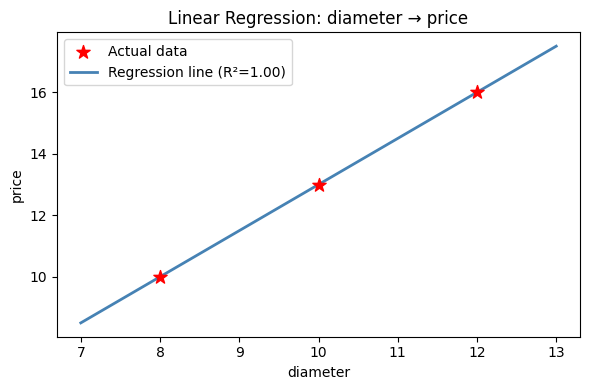

In [4]:
print("Dataset 1: Pizza/Diameter")
df1 = pd.DataFrame({"price": [10, 13, 16], "diameter": [8, 10, 12]})
model1 = LinearRegression()
model1.fit(df1, x_col="diameter", y_col="price")
model1.predict([15, 20])
model1.plot()

Dataset 2: Exam Scores/Hours Studied
Model trained on hours_studied -> exam_score
Equation: exam_score = 7.1786 × hours_studied + (42.2857)
Predict: hours_studied = 10.00  ->  exam_score = 114.0714
[score] R² = 0.9937  (excellent fit)


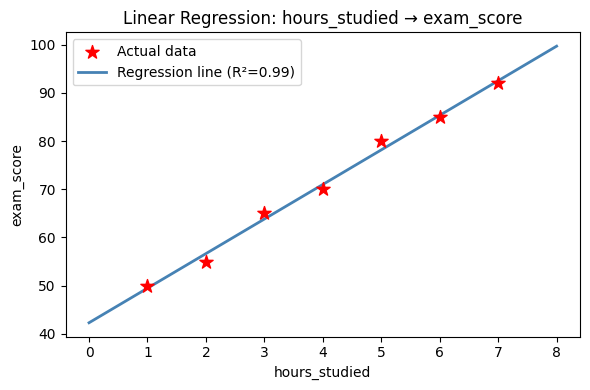

In [5]:

print("Dataset 2: Exam Scores/Hours Studied")
df2 = pd.DataFrame({
    "hours_studied": [1, 2, 3, 4, 5, 6, 7],
    "exam_score":    [50, 55, 65, 70, 80, 85, 92]
})
model2 = LinearRegression()
model2.fit(df2, "hours_studied", "exam_score")
model2.predict(10)
model2.plot()